# Mejora 3 - Ajuste fino de la regresión logística

**Proyecto - Parte 1: Machine Learning clásico**

**Estudiantes:**

[Nombre integrante 1] – [código]

[Nombre integrante 2] – [código]

**Curso:** ISIS2611 - Aprendizaje de Máquina

---

## Contexto

En el notebook principal la regresión logística se afinó con una grilla gruesa: `C` entre 0,5 y 30, con las penalizaciones L1 y L2 y varios solvers. La mejor configuración fue L1 con `C = 10`, y las cinco primeras posiciones eran todas L1 con `C` entre 3 y 30. Este notebook implementa la tercera oportunidad de mejora: **buscar con más detalle en esa zona y probar elastic net**, que combina las penalizaciones L1 y L2. Después se comprueba si la diferencia con el modelo actual es real o es ruido.

## Requisitos de la guía

| Requisito | Cómo se cumple |
|:---|:---|
| No usar aprendizaje profundo, transformers ni embeddings preentrenados. | No se usa ninguno. Todo se basa en TF-IDF y n-gramas. |
| Usar únicamente modelos de scikit-learn. | Solo `LogisticRegression`. |
| Resultados replicables. | Semillas fijas, versiones en `requirements.txt` y todo el flujo en este notebook (sección 11). |

## 1. Importación de librerías

In [1]:
import os
import re
import unicodedata
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from nltk.stem import SnowballStemmer

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, ConfusionMatrixDisplay,
                             f1_score, precision_score, recall_score)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold, cross_val_score,
                                     train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.width', 160)

RANDOM_STATE = 42
ORDEN_CLASES = ['negativo', 'neutral', 'positivo']

# Rutas del proyecto (este notebook está en la carpeta notebooks/)
RUTA_DATOS = os.path.join('..', 'data')
RUTA_MODELOS = os.path.join('..', 'models')
RUTA_ENVIOS = os.path.join('..', 'submissions')
NOMBRE_MODELO = 'regresion_logistica_ajuste_fino'

os.makedirs(RUTA_MODELOS, exist_ok=True)
os.makedirs(RUTA_ENVIOS, exist_ok=True)

## 2. Datos, partición y modelo actual

In [2]:
train = pd.read_csv(os.path.join(RUTA_DATOS, 'train.csv'))
evaluacion = pd.read_csv(os.path.join(RUTA_DATOS, 'eval.csv'))
muestra_envio = pd.read_csv(os.path.join(RUTA_DATOS, 'sample_submission.csv'))

print('train:', train.shape, '| eval:', evaluacion.shape, '| sample_submission:', muestra_envio.shape)
print('Distribución de clases en train:')
display(train['label'].value_counts(normalize=True).reindex(ORDEN_CLASES).round(3).to_frame('proporción'))

train: (12000, 3) | eval: (3000, 2) | sample_submission: (3000, 2)
Distribución de clases en train:


,proporción
label,
negativo,0.351
neutral,0.298
positivo,0.351


In [3]:
X = train[['text']]
y = train['label']

# Misma partición y mismas particiones de validación cruzada que en el notebook principal
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('Entrenamiento:', X_train.shape, '| Prueba:', X_test.shape)

Entrenamiento: (9600, 1) | Prueba: (2400, 1)


In [4]:
stemmer = SnowballStemmer('spanish')
cache_raices = {}


def raiz(palabra):
    # Se guarda la raíz de cada palabra para no repetir el stemming miles de veces
    if palabra not in cache_raices:
        cache_raices[palabra] = stemmer.stem(palabra)
    return cache_raices[palabra]


def quitar_tildes(texto):
    texto = unicodedata.normalize('NFKD', texto)
    return ''.join(c for c in texto if not unicodedata.combining(c))


def limpiar_texto(texto, stop=None, stemming=True):
    texto = quitar_tildes(texto.lower())
    texto = re.sub(r'[^\w\s]', ' ', texto)
    texto = re.sub(r'\d+', ' ', texto)
    tokens = texto.split()
    if stop:
        tokens = [t for t in tokens if t not in stop]
    if stemming:
        tokens = [raiz(t) for t in tokens]
    return ' '.join(tokens)


def separar_oraciones(texto):
    return [o.strip() for o in re.split(r'(?<=[.!?])\s+', texto) if o.strip()]


# Conectores que introducen la opinión que se impone sobre la anterior
CONECTORES = r'\b(?:pero|aunque|sin embargo|aun asi|con todo|a fin de cuentas|al final)\b'


def extraer_completo(textos, stemming=True):
    return [limpiar_texto(t, stemming=stemming) for t in textos]


def extraer_ultima(textos, stemming=True):
    return [limpiar_texto(separar_oraciones(t)[-1], stemming=stemming) for t in textos]


def extraer_clausula_final(textos, stemming=True):
    salida = []
    for t in textos:
        ultima = quitar_tildes(separar_oraciones(t)[-1].lower())
        salida.append(limpiar_texto(re.split(CONECTORES, ultima)[-1], stemming=stemming))
    return salida


def bloque_tfidf(nombre, extractor, rango=(1, 2)):
    return (nombre,
            Pipeline([('extraer', FunctionTransformer(extractor)),
                      ('tfidf', TfidfVectorizer(ngram_range=rango))]),
            'text')


def construir_representacion(bloques=('completo', 'ultima', 'clausula'), rango=(1, 2)):
    extractores = {'completo': extraer_completo,
                   'ultima': extraer_ultima,
                   'clausula': extraer_clausula_final}
    return ColumnTransformer([bloque_tfidf(b, extractores[b], rango) for b in bloques])

In [5]:
def metricas(y_real, y_pred):
    return {'Exactitud': accuracy_score(y_real, y_pred),
            'Precisión (macro)': precision_score(y_real, y_pred, average='macro'),
            'Recall (macro)': recall_score(y_real, y_pred, average='macro'),
            'F1 (macro)': f1_score(y_real, y_pred, average='macro')}

In [6]:
# Modelo actual (el del notebook principal): regresión logística L1 sobre la representación por bloques
modelo_actual = Pipeline([
    ('rep', construir_representacion()),
    ('modelo', LogisticRegression(C=10, penalty='l1', solver='liblinear', max_iter=3000, random_state=RANDOM_STATE)),
])
modelo_actual.fit(X_train, y_train)
pred_actual = pd.Series(modelo_actual.predict(X_test), index=y_test.index)

cv_actual = cross_val_score(modelo_actual, X_train, y_train, cv=kfold, scoring='f1_macro', n_jobs=-1)
print(f'Modelo actual - F1-macro en validación cruzada (train): {cv_actual.mean():.4f} +/- {cv_actual.std():.4f}')
pd.DataFrame({'Modelo actual (test)': metricas(y_test, pred_actual)}).T.round(4)

Modelo actual - F1-macro en validación cruzada (train): 0.8992 +/- 0.0072


,Exactitud,Precisión (macro),Recall (macro),F1 (macro)
Modelo actual (test),0.8946,0.8987,0.8998,0.8993


## 3. Qué se va a explorar

Los hiperparámetros que se exploran son:

- **`C`:** es el inverso de la fuerza de regularización. Un `C` menor penaliza más los coeficientes grandes.
- **`penalty`:** L1 lleva muchos coeficientes exactamente a cero (selecciona atributos), L2 los encoge sin anularlos y elastic net mezcla ambas. En elastic net, `l1_ratio` indica la proporción de L1: 0 equivale a solo L2 y 1 a solo L1.
- **`solver`:** el algoritmo de optimización. L1 y L2 se pueden resolver con `liblinear`; L2 también con `lbfgs`; elastic net solo con `saga`.

La búsqueda se hace con `GridSearchCV`, igual que en el curso, con las mismas 5 particiones y la misma métrica (F1-macro) del notebook principal. Para saber si una diferencia es real, después se compara con 15 particiones (sección 7).

## 4. Grilla fina: regularización L1 y L2

La grilla L1 usa `liblinear` con 11 valores de `C` entre 2 y 20, alrededor del valor que había ganado (10). La grilla L2 usa `liblinear` y `lbfgs` con `C` entre 3 y 300, porque la penalización L2 suele necesitar valores de `C` más altos para rendir bien. En total son 21 configuraciones.

In [7]:
# Representación por bloques + regresión logística (misma estructura del notebook principal)
pipe_lr = Pipeline([
    ('rep', construir_representacion()),
    ('modelo', LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)),
])

grilla_fina = [
    {   # Regularización L1
        'modelo__penalty': ['l1'],
        'modelo__solver': ['liblinear'],
        'modelo__C': [2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20],
    },
    {   # Regularización L2
        'modelo__penalty': ['l2'],
        'modelo__solver': ['liblinear', 'lbfgs'],
        'modelo__C': [3, 10, 30, 100, 300],
    },
]

busqueda_fina = GridSearchCV(pipe_lr, grilla_fina, cv=kfold, scoring='f1_macro', n_jobs=-1)
busqueda_fina.fit(X_train, y_train)

print('Mejores hiperparámetros:', busqueda_fina.best_params_)
print(f'F1-macro en validación cruzada: {busqueda_fina.best_score_:.4f}   (modelo actual: {cv_actual.mean():.4f})')

res_fina = pd.DataFrame(busqueda_fina.cv_results_)
res_fina = res_fina.rename(columns={'param_modelo__penalty': 'penalización', 'param_modelo__solver': 'solver',
                                    'param_modelo__C': 'C'})
res_fina[['penalización', 'solver', 'C', 'mean_test_score', 'std_test_score',
          'rank_test_score']].sort_values('rank_test_score').head(10).round(4)

Mejores hiperparámetros: {'modelo__C': 7, 'modelo__penalty': 'l1', 'modelo__solver': 'liblinear'}
F1-macro en validación cruzada: 0.8998   (modelo actual: 0.8992)


,penalización,solver,C,mean_test_score,std_test_score,rank_test_score
5,l1,liblinear,7,0.8998,0.0079,1
3,l1,liblinear,5,0.8992,0.0072,2
7,l1,liblinear,10,0.8992,0.0072,3
4,l1,liblinear,6,0.8990,0.0077,4
2,l1,liblinear,4,0.8990,0.0059,5
1,l1,liblinear,3,0.8984,0.0078,6
6,l1,liblinear,8,0.8983,0.0067,7
8,l1,liblinear,12,0.8977,0.0067,8
9,l1,liblinear,15,0.8973,0.0061,9
10,l1,liblinear,20,0.8966,0.0071,10


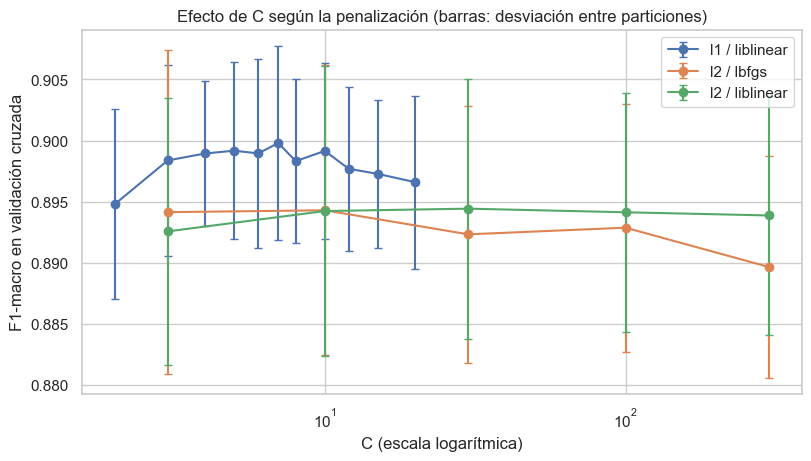

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
for (penalizacion, solver), grupo in res_fina.groupby(['penalización', 'solver']):
    grupo = grupo.sort_values('C')
    ax.errorbar(grupo['C'].astype(float), grupo['mean_test_score'], yerr=grupo['std_test_score'],
                marker='o', capsize=3, label=f'{penalizacion} / {solver}')
ax.set(xscale='log', xlabel='C (escala logarítmica)', ylabel='F1-macro en validación cruzada',
       title='Efecto de C según la penalización (barras: desviación entre particiones)')
ax.legend()
plt.show()

La mejor configuración es L1 con `C = 7`, con un F1-macro en validación cruzada de 0,8998 frente a 0,8992 del modelo actual (+0,06 puntos). Las diez mejores configuraciones son todas L1 y van de 0,8966 (`C = 20`) a 0,8998 (`C = 7`): la curva es muy plana, con apenas 0,3 puntos entre la mejor y la décima, bastante menos que la desviación entre particiones (cerca de 0,7 puntos). Ninguna configuración L2 aparece entre las diez mejores, es decir, todas quedan por debajo de 0,8966.

## 5. Elastic net

Elastic net solo se puede resolver con el solver `saga`, que en esta representación (más de 70.000 atributos) es mucho más lento que `liblinear`. Por eso la búsqueda es pequeña: `l1_ratio` en {0,5; 0,9} y `C` en {10; 30}, con un máximo de 100 iteraciones y una tolerancia de 0,001. Con ese límite el solver no llega a converger y scikit-learn lo avisa con un `ConvergenceWarning` (el aviso se repetía una vez por cada ajuste y en este notebook aparece una sola vez). Por eso los resultados de elastic net son aproximados: se podrían refinar con más iteraciones, a costa de varios minutos por ajuste.

In [9]:
pipe_en = Pipeline([
    ('rep', construir_representacion()),
    ('modelo', LogisticRegression(penalty='elasticnet', solver='saga', max_iter=100, tol=1e-3,
                                  random_state=RANDOM_STATE)),
])

grilla_en = {
    'modelo__l1_ratio': [0.5, 0.9],     # 0 = solo L2, 1 = solo L1
    'modelo__C': [10, 30],
}

busqueda_en = GridSearchCV(pipe_en, grilla_en, cv=kfold, scoring='f1_macro', n_jobs=-1)
busqueda_en.fit(X_train, y_train)

print('Mejores hiperparámetros:', busqueda_en.best_params_)
print(f'F1-macro en validación cruzada: {busqueda_en.best_score_:.4f}')

res_en = pd.DataFrame(busqueda_en.cv_results_)
res_en = res_en.rename(columns={'param_modelo__l1_ratio': 'l1_ratio', 'param_modelo__C': 'C'})
res_en['segundos por ajuste'] = res_en['mean_fit_time']
res_en[['l1_ratio', 'C', 'mean_test_score', 'std_test_score', 'segundos por ajuste', 'rank_test_score']].sort_values('rank_test_score').round(4)

/Users/nataliaerazo/.pyenv/versions/3.9.18/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Mejores hiperparámetros: {'modelo__C': 10, 'modelo__l1_ratio': 0.5}
F1-macro en validación cruzada: 0.8973


,l1_ratio,C,mean_test_score,std_test_score,segundos por ajuste,rank_test_score
0,0.5,10,0.8973,0.0110,173.8670,1
1,0.9,10,0.8972,0.0094,74.4328,2
3,0.9,30,0.8969,0.0107,132.6838,3
2,0.5,30,0.8966,0.0106,267.3817,4


In [10]:
mejor_l1 = res_fina.sort_values('rank_test_score').iloc[0]
print(f'Segundos por ajuste -> mejor L1 con liblinear: {mejor_l1["mean_fit_time"]:.1f} | elastic net con saga: {res_en["mean_fit_time"].mean():.1f}')

Segundos por ajuste -> mejor L1 con liblinear: 8.1 | elastic net con saga: 162.1


Las cuatro configuraciones de elastic net quedan entre 0,8966 y 0,8973 de F1-macro, es decir, por debajo del modelo actual (0,8992) y de la mejor L1 (0,8998). Además cuestan mucho más: cerca de 162 segundos por ajuste en promedio frente a 8,1 segundos de L1 con `liblinear`, unas 20 veces más (los tiempos exactos dependen de la carga del computador). En este rango de hiperparámetros y con este límite de iteraciones, elastic net no mejora y no compensa el costo.

## 6. Comparación en el conjunto de prueba

In [11]:
candidatos = {
    'Modelo actual (L1, C=10)': modelo_actual,
    'Mejor L1/L2 de la grilla fina': busqueda_fina.best_estimator_,
    'Mejor elastic net': busqueda_en.best_estimator_,
}
cv_candidatos = {'Modelo actual (L1, C=10)': cv_actual.mean(),
                 'Mejor L1/L2 de la grilla fina': busqueda_fina.best_score_,
                 'Mejor elastic net': busqueda_en.best_score_}

filas = {}
predicciones = {}
for nombre, modelo in candidatos.items():
    predicciones[nombre] = modelo.predict(X_test)
    filas[nombre] = {'F1-macro (CV)': cv_candidatos[nombre], **metricas(y_test, predicciones[nombre])}
tabla_comp = pd.DataFrame(filas).T
tabla_comp.round(4)

,F1-macro (CV),Exactitud,Precisión (macro),Recall (macro),F1 (macro)
"Modelo actual (L1, C=10)",0.8992,0.8946,0.8987,0.8998,0.8993
Mejor L1/L2 de la grilla fina,0.8998,0.8975,0.9013,0.9026,0.9019
Mejor elastic net,0.8973,0.8921,0.8960,0.8975,0.8966


En el conjunto de prueba, la mejor L1 de la grilla fina obtiene una exactitud de 0,8975 y un F1-macro de 0,9019, frente a 0,8946 y 0,8993 del modelo actual (+0,29 y +0,26 puntos). El mejor elastic net queda por debajo (0,8921 y 0,8966). Con 2.400 reseñas, una diferencia de 0,29 puntos equivale a unas 7 reseñas, que no es concluyente por sí sola: hay que ver si se sostiene con más particiones.

## 7. ¿La diferencia es real? Comparación con 15 particiones

Se compara la configuración fina con el modelo actual sobre 15 particiones (3 repeticiones de validación cruzada de 5 particiones, semillas 1, 2 y 3), las mismas para ambos, y se mira la diferencia partición por partición. La regla es la misma que en el notebook de validación cruzada repetida: se considera una mejora si la diferencia media supera 2 errores estándar y la alternativa gana en al menos 12 de las 15 particiones.

In [12]:
semillas = [1, 2, 3]
particiones = []
for semilla in semillas:
    particiones += list(StratifiedKFold(n_splits=5, shuffle=True, random_state=semilla).split(X_train, y_train))

nombre_mejor = 'Mejor L1/L2 de la grilla fina' if busqueda_fina.best_score_ >= busqueda_en.best_score_ else 'Mejor elastic net'
mejor_estimador = candidatos[nombre_mejor]
print('Configuración que se compara con el modelo actual:', nombre_mejor)
print(mejor_estimador.named_steps['modelo'].get_params()['penalty'], '|', 'C =', mejor_estimador.named_steps['modelo'].C)

f1_actual = cross_val_score(clone(modelo_actual), X_train, y_train, cv=particiones, scoring='f1_macro', n_jobs=-1)
f1_nuevo = cross_val_score(clone(mejor_estimador), X_train, y_train, cv=particiones, scoring='f1_macro', n_jobs=-1)

diferencia = f1_nuevo - f1_actual
error = diferencia.std(ddof=1) / np.sqrt(len(diferencia))
print(f'\nF1-macro medio (15 particiones) -> modelo actual: {f1_actual.mean():.4f} | configuración fina: {f1_nuevo.mean():.4f}')
print(f'Diferencia media: {diferencia.mean():+.4f} (error estándar {error:.4f})')
print(f'La configuración fina mejora en {(diferencia > 0).sum()} de 15 particiones')
print('Veredicto:', 'mejora' if diferencia.mean() > 2 * error and (diferencia > 0).sum() >= 12 else
      'empeora' if diferencia.mean() < -2 * error else 'no hay diferencia clara (empate)')

Configuración que se compara con el modelo actual: Mejor L1/L2 de la grilla fina
l1 | C = 7



F1-macro medio (15 particiones) -> modelo actual: 0.8967 | configuración fina: 0.8974
Diferencia media: +0.0007 (error estándar 0.0005)
La configuración fina mejora en 8 de 15 particiones
Veredicto: no hay diferencia clara (empate)


La configuración fina mejora al modelo actual en 0,07 puntos de F1-macro (error estándar de 0,05 puntos) y gana en 8 de las 15 particiones. Es un empate. La ventaja de 0,29 puntos que se veía en el conjunto de prueba no se sostiene: es lo esperable cuando se escoge la mejor de 21 configuraciones casi iguales, porque la ganadora tiende a verse un poco mejor de lo que realmente es (parte de su ventaja es suerte de esa partición).

## 8. Modelo final y predicciones para la competencia

Siguiendo el procedimiento del curso, el modelo final es el mejor estimador de la búsqueda (L1 con `C = 7`), aunque la comparación pareada indica que no es distinguible del modelo actual (`C = 10`). Se entrena con las 12.000 reseñas etiquetadas y se predice `eval.csv`.

In [13]:
modelo_final = clone(mejor_estimador)
modelo_final.fit(X, y)

pred_eval = modelo_final.predict(evaluacion[['text']])
envio = pd.DataFrame({'id': evaluacion['id'], 'answer': pred_eval})
envio.to_csv(os.path.join(RUTA_ENVIOS, f'submission_{NOMBRE_MODELO}.csv'), index=False)

print('Mismas columnas que sample_submission:', list(envio.columns) == list(muestra_envio.columns))
print('Mismos ids y en el mismo orden:', (envio['id'] == muestra_envio['id']).all())

envio_actual = pd.read_csv(os.path.join(RUTA_ENVIOS, 'submission_regresion_logistica_bloques.csv'))
distintas = (envio['answer'] != envio_actual['answer']).sum()
print(f'Predicciones distintas respecto al envío del modelo actual: {distintas} de {len(envio)}')
display(pd.DataFrame({'train (real)': train['label'].value_counts(normalize=True),
                      'eval (predicho)': envio['answer'].value_counts(normalize=True)}).reindex(ORDEN_CLASES).round(3))

Mismas columnas que sample_submission: True
Mismos ids y en el mismo orden: True
Predicciones distintas respecto al envío del modelo actual: 30 de 3000


,train (real),eval (predicho)
negativo,0.351,0.353
neutral,0.298,0.282
positivo,0.351,0.366


In [14]:
ruta_modelo = os.path.join(RUTA_MODELOS, f'{NOMBRE_MODELO}.joblib')
joblib.dump(modelo_final, ruta_modelo)

modelo_cargado = joblib.load(ruta_modelo)
print('El modelo guardado reproduce exactamente las mismas predicciones:',
      (modelo_cargado.predict(evaluacion[['text']]) == pred_eval).all())

El modelo guardado reproduce exactamente las mismas predicciones: True


Este modelo cambia solo 30 de las 3.000 predicciones (1,0%) respecto al envío del modelo actual. Dado que la diferencia real entre ambos es de menos de 0,1 puntos, se espera que su puntaje de Kaggle sea prácticamente el mismo (una diferencia de unas décimas de punto sería ruido). Subirlo como un envío adicional no aporta información nueva.

## 9. Conclusiones

- **El ajuste fino de `C` no mejora el modelo de forma real.** La mejor configuración (L1, `C = 7`) supera al modelo actual por 0,06 puntos en validación cruzada y por 0,29 puntos en el conjunto de prueba, pero con 15 particiones la diferencia es de 0,07 puntos y no se distingue del ruido (empate, 8 de 15 particiones).
- **La zona de `C` entre 3 y 20 es una meseta.** Las diez mejores configuraciones están dentro de 0,3 puntos entre sí. El modelo actual (`C = 10`) ya estaba en esa meseta.
- **Elastic net no ayuda y es muy caro.** Quedó por debajo de L1 (0,8973 contra 0,8998) y tarda unas 20 veces más por ajuste, además de no converger con el límite de iteraciones usado.
- **Para Kaggle,** este envío cambia solo 30 predicciones respecto al modelo actual y se espera el mismo puntaje. No es una apuesta que valga la pena frente a las otras mejoras.

## 10. Uso de herramientas de IA generativa

**Declaración del uso.** Se utilizó Claude Code (modelo Claude Sonnet 5.5, de Anthropic) como apoyo para: proponer y generar un primer esqueleto del código de este notebook, depurar errores y redactar las explicaciones.

**Prompts utilizados.**

1. *"implementemos las 3 oportunidades de mejora en 3 jupyters nuevos"*, después de que la herramienta resumiera las oportunidades de mejora del modelo del notebook principal (modelo por oración, validación cruzada repetida y ajuste fino de la regresión logística).

**Análisis crítico del resultado.**

[Completar por el equipo: ¿qué partes del código y de las explicaciones generadas fueron correctas y útiles? ¿qué errores, imprecisiones o limitaciones se identificaron? ¿qué decisiones técnicas se cambiaron respecto a lo que propuso la herramienta y por qué? ¿qué conceptos del curso permitieron evaluar o corregir la respuesta?]

**Aportes propios del equipo.**

[Completar por el equipo: qué se desarrolló, modificó o decidió, qué ajustes se hicieron al código y a las explicaciones, y qué se aprendió del proceso.]

## 11. Cómo replicar los resultados

1. Crear un entorno con Python 3.9 e instalar las librerías con `pip install -r requirements.txt` (están en la raíz del proyecto).
2. Mantener la estructura de carpetas del proyecto: este notebook está en `notebooks/`, los datos en `data/`. El notebook se ejecuta desde la carpeta `notebooks/`.
3. Ejecutar todas las celdas en orden (`Restart & Run All`). Tarda aproximadamente 11 minutos (la mayor parte, por el elastic net).
4. Al terminar se generan `models/regresion_logistica_ajuste_fino.joblib` y `submissions/submission_regresion_logistica_ajuste_fino.csv`.

Todas las fuentes de aleatoriedad usan semillas fijas, por lo que las cifras se reproducen exactamente con las versiones de `requirements.txt`. Para cargar el modelo guardado fuera del notebook hay que ejecutar antes las celdas que definen las funciones usadas por el pipeline.